# I. Condorcet's Jury Theorem (1785) (15 points)

Assume voter probability to be correct is $p>.5$.

1. Plot the probability a jury of $n$ voters (odd) is correct as a function of $p$ for different $n$ using Monte-Carlo simulations (sampling and averaging).

2. Prove that as number of jury members grows, $n\rightarrow\infty$, the  jury majority becomes correct  $\Pr(\text{correct}) \rightarrow 1$ (**hint**: use the law of large numbers).

Notes: Avoid loops where possible.

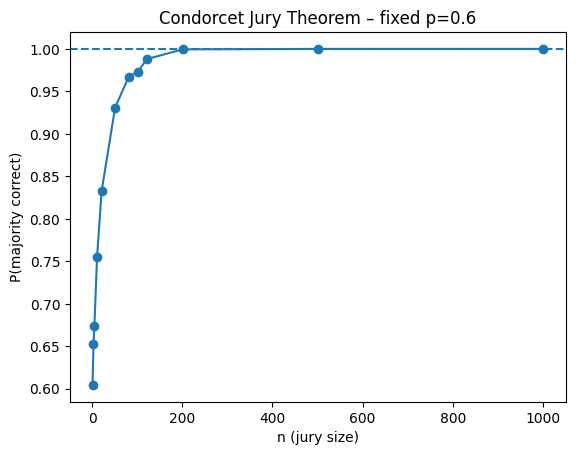

In [20]:
# Implement here
# for question 1:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_for_fixed_p(p, n_array, trials=2000):
    rng = np.random.default_rng(0)
    probs = []

    for n in n_array:
        # (trials X n) matrix of 0-1 numbers, than check for each number if lower than p - if so = true, else: false
        votes = rng.random((trials, n)) < p
        # calculate sum per row
        sums = votes.sum(axis=1)
        # if majority were correct the row appears in maj as True, else False. take the mean (how many trials the jury was coorect)
        maj = sums > (n // 2)
        probs.append(maj.mean())

    return np.array(probs)

p = 0.6
ns = [1, 3, 5, 11, 21, 51, 81, 101, 121, 201, 501, 1001]

est = monte_carlo_for_fixed_p(p, ns, trials=2000)

plt.plot(ns, est, marker='o')
plt.axhline(1, linestyle='--')
plt.xlabel("n (jury size)")
plt.ylabel("P(majority correct)")
plt.title(f"Condorcet Jury Theorem – fixed p={p}")
plt.show()

#for question 2:
# First of all, we can see that the graph proves that as number of jury members grows,  n→∞ , the jury majority becomes correct: Pr(correct)→1.
# proof:

# Model each voter i as an i.i.d. Bernoulli random variable:
#   Xi = 1 if voter i is correct, 0 otherwise, with P(Xi=1)=p and p > 0.5.
# Let Sn = X1 + ... + Xn be the number of correct votes in a jury of size n,
# and let X_n = Sn / n be the fraction of correct votes.
#
# The majority decision is correct if Sn > n/2, i.e. if X_n > 0.5:
#   P(majority correct) = P(Sn > n/2) = P(X_n > 0.5).
#
# By the Law of Large Numbers, since Xi are i.i.d. with E[Xi]=p:
#   as n -> infinity: X_n -> p .
#
# Because p > 0.5, define: epsilon = p - 0.5.
# Then LLN implies:
#   P(|X_n - p| < epsilon) -> 1.
# But if |X_n - p| < epsilon, then
#   X_n > p - epsilon. and: p - (p - 0.5) = 0.5,
# so this event guarantees a correct majority. (because X_n > 0.5)
# Therefore:
#   P(X_n > 0.5) >= P(|X_n - p| < epsilon). and P(|X_n - p| < epsilon) -> 1,
# hence as n -> infinity : P(majority correct) -> 1 . for any fixed p > 0.5.



Your proves goes here

# II. AdaBoost + Semi Supervised (35 points)
Obtaining labeled data is expensive in many real-world scenarios, but unlabeled data is abundant. Semi-supervised learning allows us to improve model performance by leveraging unlabeled data.

In this assignment, you will train an ensemble model (AdaBoost) on a small labeled dataset and then explore how to improve it using additional unlabeled data.

You will use one of the most common image datasets: CIFAR10. The CIFAR-10 dataset (Canadian Institute For Advanced Research) is a collection of images that are commonly used to train machine learning and computer vision algorithms. [See more](https://en.wikipedia.org/wiki/CIFAR-10)



In [22]:
# Downloading the dataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import cifar10

# Load CIFAR-10 dataset. 50K train, 10K test
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

# Split the training set into 2K labeled and 48K unlabeled samples
x_labeled, x_unlabeled, y_labeled, _ = train_test_split(
    x_train, y_train, train_size=2000, stratify=y_train, random_state=42)

**Answer the following questions:**

### EDA - Exploratory Data Analysis (10 pts):
Explore the cifar10 dataset, provide at least three plot-based conclusions about the dataset, and print sample images from each class.

***Write your code below***

x_train shape: (50000, 32, 32, 3)
x_test  shape: (10000, 32, 32, 3)
Number of training samples: 50000
Number of test samples: 10000
Image size: (32, 32, 3)
Number of features per image: 3072
Discovered class labels: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


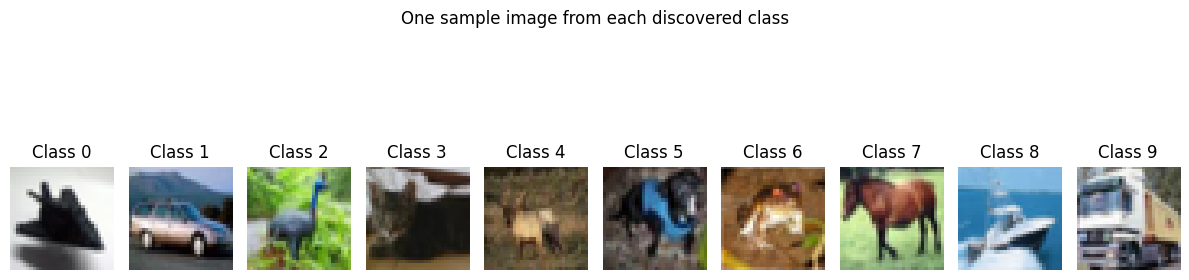

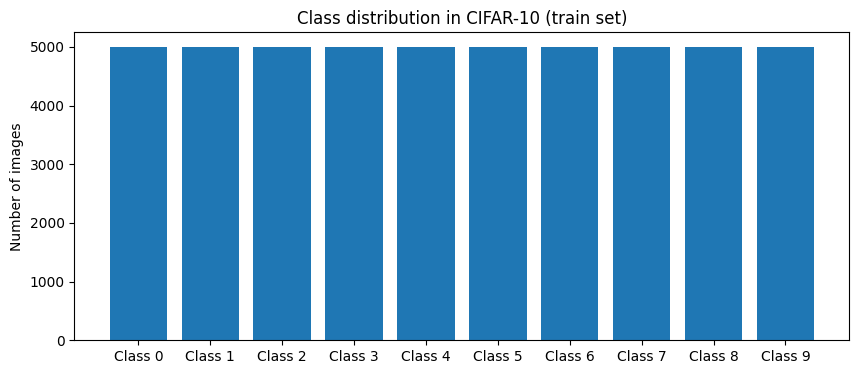

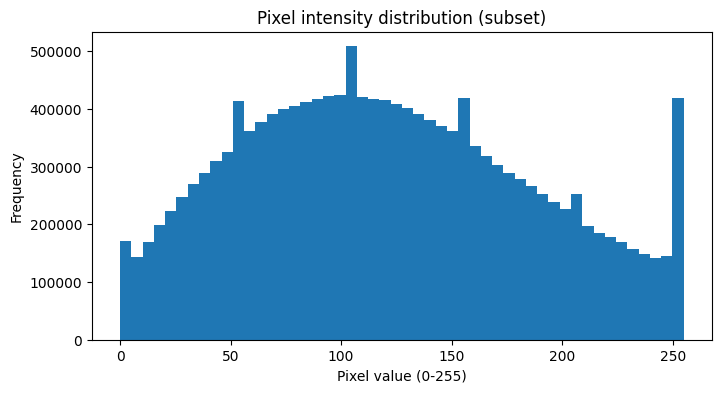

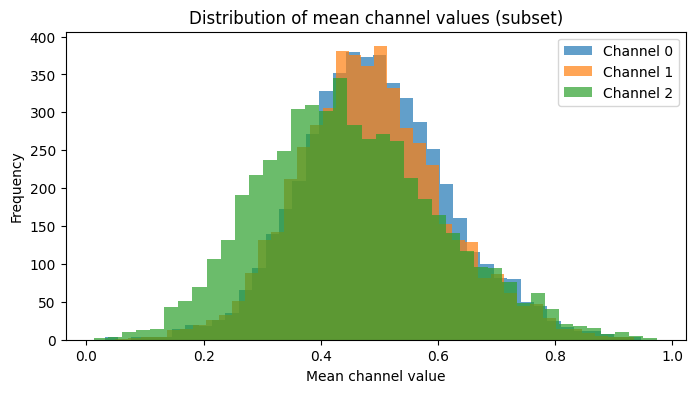

In [23]:
# Note: conclusions are written in comments

import numpy as np
import matplotlib.pyplot as plt

# 1) Explore the dataset (ONLY from the data)

print("x_train shape:", x_train.shape)
print("x_test  shape:", x_test.shape)

# number of samples
n_train = x_train.shape[0]
n_test  = x_test.shape[0]

# image dimensions
img_h, img_w, img_c = x_train.shape[1:]

# number of features per image
n_features = img_h * img_w * img_c

# discover classes from labels
unique_labels = np.unique(y_train)
n_classes = len(unique_labels)

print("Number of training samples:", n_train)
print("Number of test samples:", n_test)
print("Image size:", (img_h, img_w, img_c))
print("Number of features per image:", n_features)
print("Discovered class labels:", unique_labels)
print("Number of classes:", n_classes)

# 2) Print sample images from each class (without assuming class names)

plt.figure(figsize=(12,4))

for i, c in enumerate(unique_labels):
    idx = np.where(y_train == c)[0][0]   # first image of class c
    plt.subplot(1, n_classes, i+1)
    plt.imshow(x_train[idx])
    plt.title(f"Class {c}")
    plt.axis("off")

plt.suptitle("One sample image from each discovered class")
plt.tight_layout()
plt.show()

# 3) First Plot-based examination: Class distribution
counts = np.array([(y_train == c).sum() for c in unique_labels])

plt.figure(figsize=(10,4))
plt.bar([f"Class {c}" for c in unique_labels], counts)
plt.ylabel("Number of images")
plt.title("Class distribution in CIFAR-10 (train set)")
plt.show()

# After watching:
# This is the conclusion:
# The dataset contains 10 classes with approximately similar number of samples per class.

# 4) Second Plot-based examination: Pixel intensity histogram

rng = np.random.default_rng(0)
subset_idx = rng.choice(n_train, size=5000, replace=False)
pixels = x_train[subset_idx].reshape(-1)

plt.figure(figsize=(8,4))
plt.hist(pixels, bins=50)
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Frequency")
plt.title("Pixel intensity distribution (subset)")
plt.show()

# After watching: Conclusions:
# The wide spread of pixel values indicates high visual diversity, making the classification task non-trivial.
# The high variability and noise in the images suggest that learning from a small labeled set is challenging,
# which motivates the use of unlabeled data in a semi-supervised learning approach.

# 5) Plot-based conclusion #3: RGB channel statistics
subset = x_train[subset_idx].astype(np.float32) / 255.0
channel_means = subset.mean(axis=(1,2))

plt.figure(figsize=(8,4))
plt.hist(channel_means[:,0], bins=40, alpha=0.7, label="Channel 0")
plt.hist(channel_means[:,1], bins=40, alpha=0.7, label="Channel 1")
plt.hist(channel_means[:,2], bins=40, alpha=0.7, label="Channel 2")
plt.xlabel("Mean channel value")
plt.ylabel("Frequency")
plt.title("Distribution of mean channel values (subset)")
plt.legend()
plt.show()

# After watching: Conclusions:

# The RGB channels show similar distributions, so no single color dominates the data.
# This means classification depends on combined color information.
# Such complexity motivates using more data (including unlabeled) to improve learning




### Model training and evaluating (10 pts):
Use the x_labeled and y_labeled to train an AdaBoost model, classify the images, and evaluate it using the testing set.

***Write your code below***

In [26]:
# Implement here

import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1) Prepare the data

# Flatten images: each image (32x32x3) becomes a vector of length 3072
X_labeled = x_labeled.reshape(x_labeled.shape[0], -1).astype(np.float32)

# Normalize pixel values from [0,255] to [0,1] for train and test
X_labeled = X_labeled / 255.0

X_test = x_test.reshape(x_test.shape[0], -1).astype(np.float32)
X_test = X_test / 255.0


# 2) Define the weak learner: A very small decision tree: depth=1 means it makes only one simple decision

base_learner = DecisionTreeClassifier(max_depth=2, random_state=42)

# 3) Build the AdaBoost model

ada = AdaBoostClassifier(
    estimator=base_learner,   # the weak learner to boost
    n_estimators=60,        # number of boosting rounds
    learning_rate=0.5,       # scales the alpha of each tree
    random_state=42)

# 4) Train the model

# AdaBoost will:
# - train 200 trees, one after another
# - after each tree: compute its error, compute its alpha (importance), increase the weight of misclassified samples

ada.fit(X_labeled, y_labeled)

# 6) Predict on the test set

y_pred = ada.predict(X_test)

# 7) Evaluate the model

acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", round(acc, 4))



Test Accuracy: 0.278


### Semi-Supervised usage (5 pts):
Explain how you would use the additional data (x_unlabeled) to improve your model performance.

#### Explain here:

Using the unlabeled data can help us improve the model, this is how we"ll do it:
We will predict values for the unlabled data and add the confident samples as labled data. steps:

First, the trained AdaBoost model predicts labels for the unlabeled images.
Then, we keep only the samples for which the model is very confident.
These high-confidence predictions are treated as new labeled data.
Finally, we retrain the model on the enlarged dataset.
This increases the effective number of labeled samples and improves generalization.



### Semi-supervised training (10 pts):
Retrain the new model using x_labeled, x_unlabeled, and y_labeled, evaluate it using the testing set, and show the improvement.

***Write your code below***

In [27]:
# 1) Prepare unlabeled data (same preprocessing)
X_unlabeled = x_unlabeled.reshape(x_unlabeled.shape[0], -1).astype(np.float32) / 255.0

# 2) Predict probabilities, pseudo-labels, and confidence
probabilities = ada.predict_proba(X_unlabeled)
max_y = np.argmax(probabilities, axis=1)
conf  = np.max(probabilities, axis=1)

n_to_add = 1000
indices = np.argsort(conf)[-n_to_add:]
X_chosen = X_unlabeled[indices]
y_chosen = max_y[indices]

# Verify selection
print(f"Added {len(X_chosen)} samples.")
print(f"Confidence range of added samples: {conf[indices].min():.4f} to {conf[indices].max():.4f}")


# 4) Combine labeled + chosen pseudo-labeled
X_new = np.vstack([X_labeled, X_chosen])
y_new = np.concatenate([y_labeled, y_chosen])

# 5) Retrain new model (KEEP same strength as baseline!)
ada_new = AdaBoostClassifier(
    estimator=base_learner,
    n_estimators=60,        # same as baseline
    learning_rate=0.5,
    random_state=42)

ada_new.fit(X_new, y_new)

# 6) Evaluate
y_pred_new = ada_new.predict(X_test)
acc_new = accuracy_score(y_test, y_pred_new)

print("Baseline Accuracy:", round(acc, 4))
print("Semi-supervised Accuracy:", round(acc_new, 4))
print("Improvement:", round(acc_new - acc, 4))


Added 1000 samples.
Confidence range of added samples: 0.1021 to 0.1036
Baseline Accuracy: 0.278
Semi-supervised Accuracy: 0.2805
Improvement: 0.0025


**Conclusion:**

 The method didn't help a lot because it's clear that there are no samples with high probability of a class. the highest is 0.1036 which is almost random, but in other cases the method would help. we could use PCA or data augmentation to support it but id doesn't fit the instructions.

---
# Section 2 - Features (50 Points)
---


### Machine Learning Assignment: Feature Generation, Feature Engineering, and Feature Selection

#### Objective:
The goal of this section is to give you hands-on experience with feature generation, feature engineering, and feature selection using a real-world dataset. You will preprocess the data, create new features, engineer existing features, and select the most relevant features for a machine learning model.

#### Dataset:
For this assignment, you will use the [UCI Machine Learning Repository's "Wine Quality Dataset"](https://archive.ics.uci.edu/ml/datasets/wine+quality). This dataset consists of various physicochemical tests of wine to predict the quality.

1. ## **Data Preprocessing:** (5 points)
   - Load the dataset and perform basic preprocessing steps including handling missing values, encoding categorical variables if any, and normalizing the data.

In [1]:
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features.copy()
y = wine_quality.data.targets.copy()

# Build df :
df = X.copy()
df["quality"] = y.values  # adds the target column


## EDA - Exploratory Data Analysis (5 pts):
Use any visual tools to present and explain the data. Your answer must include statistics, images, and conclusions.

***Write your code below***


       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

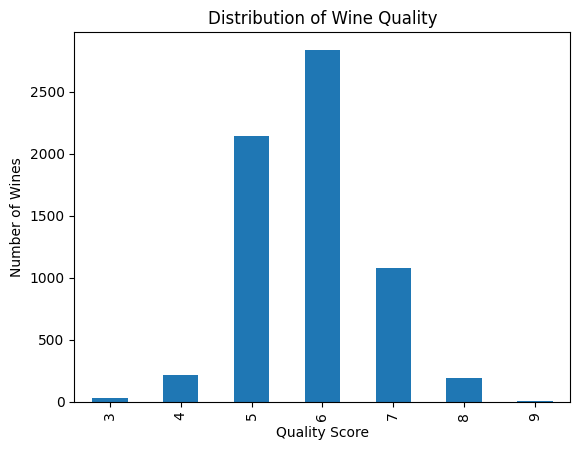

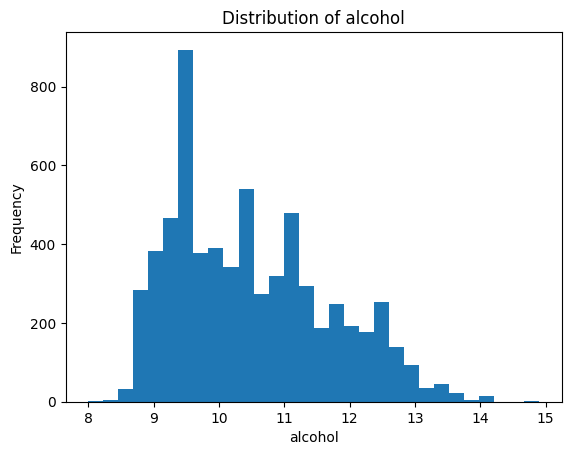

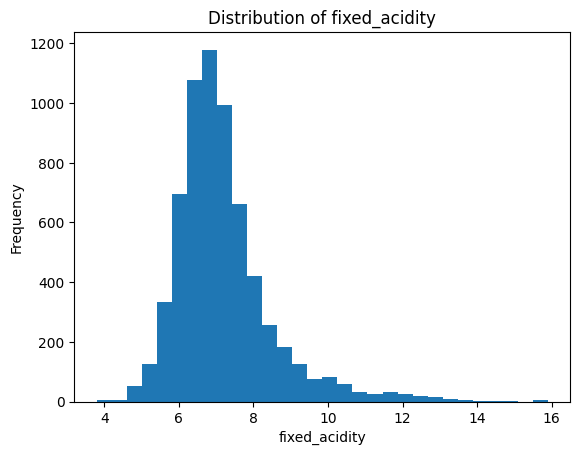

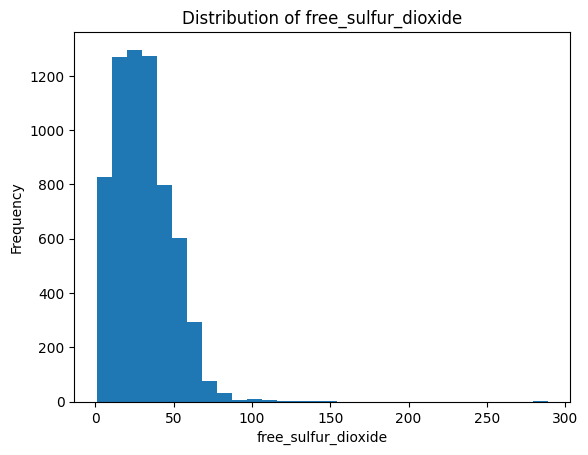

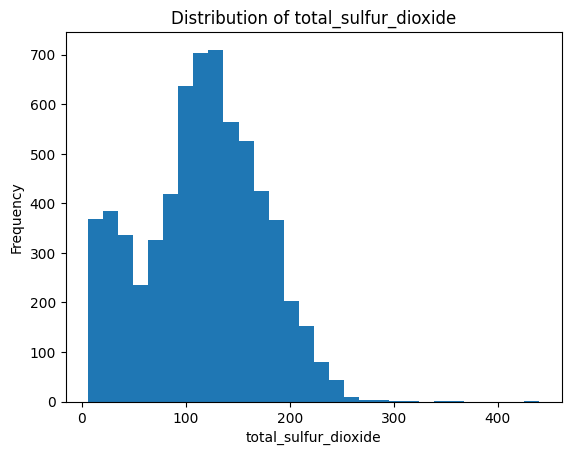

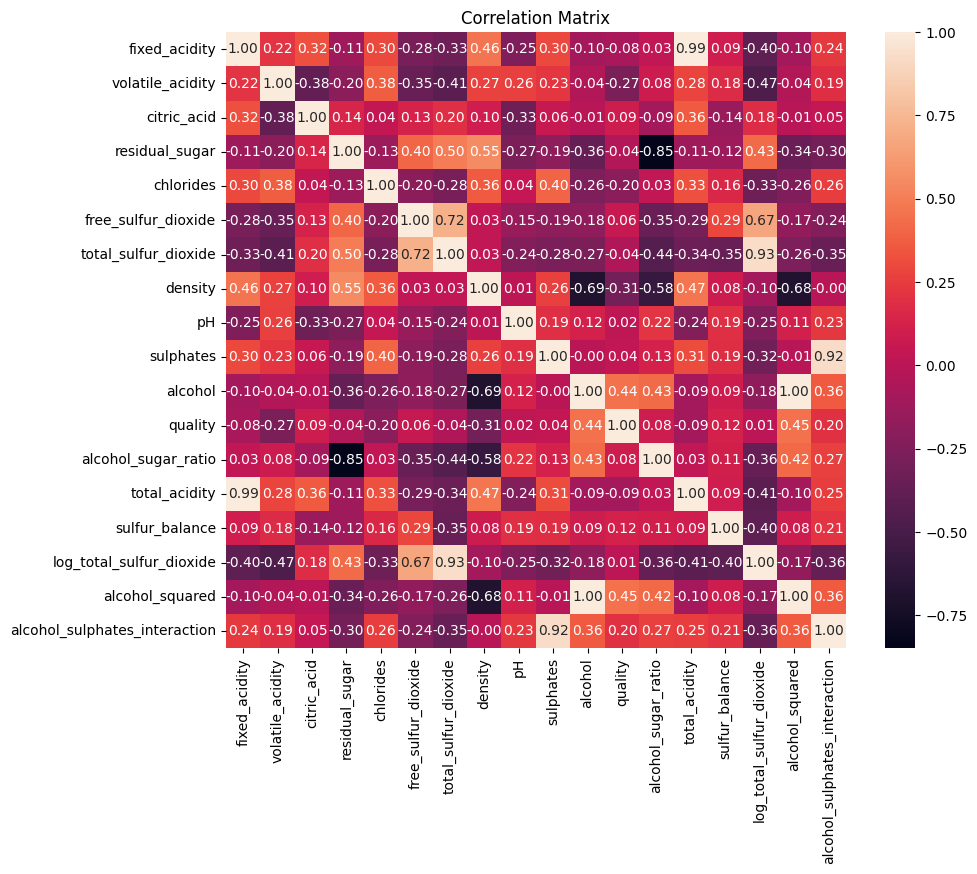

Correlation of each feature with quality:
alcohol_squared                  0.446175
alcohol                          0.444319
alcohol_sulphates_interaction    0.201076
sulfur_balance                   0.120681
citric_acid                      0.085532
alcohol_sugar_ratio              0.084031
free_sulfur_dioxide              0.055463
sulphates                        0.038485
pH                               0.019506
log_total_sulfur_dioxide         0.008780
residual_sugar                  -0.036980
total_sulfur_dioxide            -0.041385
fixed_acidity                   -0.076743
total_acidity                   -0.094240
chlorides                       -0.200666
volatile_acidity                -0.265699
density                         -0.305858
Name: quality, dtype: float64


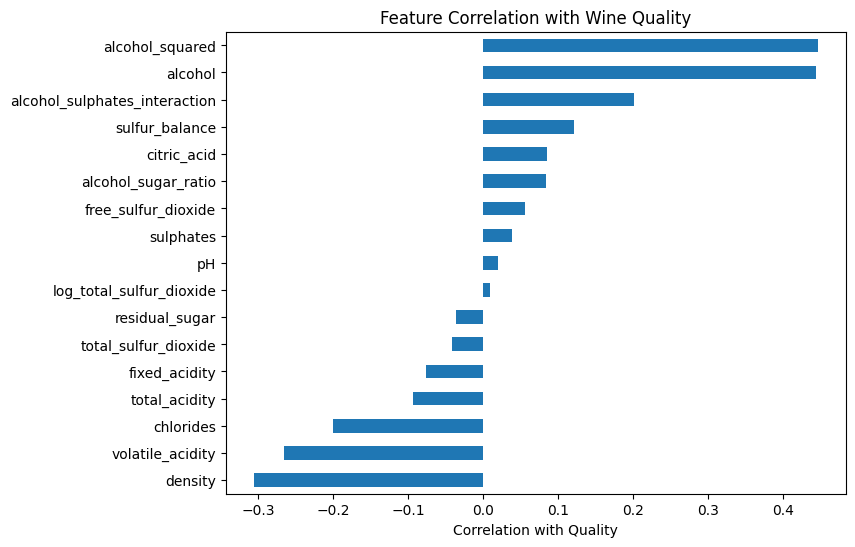

In [13]:
# Code here and conclusions at the cell below:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# general overview
print(df.describe())

#  Target Distribution
plt.figure()
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

# 3. Feature Distributions - for those with high variance by describe()

features = ["alcohol", "fixed_acidity", "free_sulfur_dioxide", "total_sulfur_dioxide"]

for col in features:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# The heatma of coorelation between every 2 features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# each feature correlation to quality:
correlations = df.corr()["quality"].drop("quality")
correlations_sorted = correlations.sort_values(ascending=False)

print("Correlation of each feature with quality:")
print(correlations_sorted)

plt.figure(figsize=(8,6))
correlations_sorted.plot(kind="barh")
plt.xlabel("Correlation with Quality")
plt.title("Feature Correlation with Wine Quality")
plt.gca().invert_yaxis()
plt.show()






In [3]:
# Explain here

# Conclusions:
# 1. from describe() we can say there is not missing data
# 2. from describe() we can say that there is a different scale for values of features, so normalization is needed.
# 3. from the target distribution: the data is not quite balanced - most wines qualities are 5-6, the data is imbalanced.
# 4. from the feature distributions:
# Alcohol exhibits a right-skewed distribution with a medium range of values, indicating high variance and potential imprtance of the feature.
# Both free and total sulfur dioxide display highly skewed distributions with long right tails,
# suggesting that extreme preservation levels may effect the quality and be valuable features.
# Overall, the analysis highlights alcohol, acidity measures, and sulfur dioxide as important and informative features for further modeling.
# 5. from heatmap: high correlation between free_sulfur_dioxide and total_sulfur_sioxide (natural connection), and between density and alcohol. (negative correlation).
# 6. from correlation with quality: alcohol mainly has positive meaningful relation to quality.
# density has a negative strong connection to quality.

2. ## **Feature Generation:** (5 points)
   - Create at least three new features from the existing data. Explain your reasoning behind the creation of these features.
   - Example: You might create a new feature that is the ratio of alcohol to residual sugar.

In [4]:
# Implement here
# 1. alcohol to resifula sugar ratio:
df["alcohol_sugar_ratio"] = df["alcohol"] / (df["residual_sugar"] + 1)

# 2. Total Acidity Index
df["total_acidity"] = (df["fixed_acidity"] + df["volatile_acidity"] + df["citric_acid"])

# 3. Sulfur Balance
df["sulfur_balance"] = (df["free_sulfur_dioxide"] / (df["total_sulfur_dioxide"] + 1))



In [5]:
# Explain here
#1. alcohol to resifula sugar ratio: This feature represents the balance between the strength of the wine (alcohol)
# and its sweetness (residual sugar). Wines with the same alcohol level can taste
# very different depending on how sweet they are, so this ratio provides a more informative measure than using alcohol or sugar alone.
#2. Total Acidity Index: This feature combines all major acidity-related measurements into a single value.
# Instead of treating fixed acidity, volatile acidity, and citric acid separately.
#3. Sulfur Balance: This feature measures how much of the total sulfur dioxide is actually active.
# Free sulfur dioxide is the effective preservative, while total sulfur dioxide
# includes both active and inactive forms.

3. ## **Feature Engineering:** (10 points)
   - Engineer at least three features from the existing data by transforming the original features.
   - Example: You could create polynomial features, interaction features, or apply log transformations.

In [6]:
# Implement here

# 1. Log transformation on Total Sulfur Dioxide
df["log_total_sulfur_dioxide"] = np.log1p(df["total_sulfur_dioxide"])

# 2. Polynomial feature for Alcohol
df["alcohol_squared"] = df["alcohol"] ** 2

# 3.Interaction feature: Alcohol × Sulphates
df["alcohol_sulphates_interaction"] = (df["alcohol"] * df["sulphates"])



In [7]:
# Explain here
# 1. Log transformation on Total Sulfur Dioxide: This feature is highly right-skewed. Applying a log transformation
# reduces the impact of extreme values and makes the distribution

# 2. Polynomial feature for Alcohol
# The relationship between alcohol and wine quality is strong in linear terms, but it might be strong in not linear connection as well.
# We would like to give it a chance. By squaring the alcohol feature, we allow the model to capture
# potential non-linear effects.

# 3. Interaction feature: Alcohol × Sulphates
# This feature captures the combined effect of alcohol content and sulphates level.
# Alcohol is positively correlated with wine quality, and sulphates also contributes but much less. By multiplying them, we allow the model to learn situations
# where having both high alcohol and adequate sulphates together may have a stronger influence. it might increase sulphates's imfluence and give advanced insights.

4. ## **Feature Selection:** (5 points)
   - Apply at least two different feature selection methods to identify the most important features.
   - Example methods: Recursive Feature Elimination (RFE), Lasso Regression, or mutual information, NMF.
   - Compare the selected features from each method and discuss the differences.

In [8]:
# Implement here
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

# Prepare:

X = df.drop("quality", axis=1)
y = df["quality"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#RFE:

# We use a linear regression model as the base estimator.
# RFE will rely on this model to evaluate the importance of each feature.
model = LinearRegression()

# We ask RFE to keep only 5 features in the final selection.
rfe = RFE(estimator=model, n_features_to_select=5)
# Removes the weakest feature until only 5 features remain.
rfe.fit(X_scaled, y)

# rfe.support_ is a boolean mask indicating which features were selected.
rfe_features = X.columns[rfe.support_]

print("Selected features by RFE:")
print(rfe_features)

# LASSSO:

# Create and fit the Lasso model
# alpha controls how aggressive the feature selection is
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y)

# Get the coefficients learned by Lasso
coefficients = pd.Series(lasso.coef_, index=X.columns)

# Keep only features with non-zero coefficients
selected_by_lasso = coefficients[coefficients != 0]

# Sort features by the absolute value of their coefficients
top5_lasso = selected_by_lasso.abs().sort_values(ascending=False).head(5)

print("Top 5 features selected by Lasso:")
print(top5_lasso)





Selected features by RFE:
Index(['fixed_acidity', 'volatile_acidity', 'alcohol', 'sulfur_balance',
       'alcohol_squared'],
      dtype='object')
Top 5 features selected by Lasso:
alcohol_squared                  0.360335
volatile_acidity                 0.231825
sulfur_balance                   0.096266
alcohol_sulphates_interaction    0.084473
alcohol_sugar_ratio              0.079488
dtype: float64


In [22]:
# Explain here

# The differences between the selected features is originated in the distinct selection mechanisms
# of RFE and Lasso. RFE performs an iterative, performance-based elimination process, which
# tends to favor features that contribute through complementary and non-linear effects.
# This explains why RFE selected features such as alcohol_squared and sulfur_balance,
# which capture non-linear behavior and chemical relationships beyond simple linear impact.

# Lasso applies regularization, shrinking weak coefficients to zero and
# therefore prioritizing features with strong independent predictive power. This is why
# Lasso emphasized alcohol_squared, volatile_acidity, and alcohol_sugar_ratio — features
# that show a clear and direct relationship with wine quality.

# The fact that both methods consistently selected alcohol_squared, volatile_acidity,
# and sulfur_balance indicates that these features are robust and stable predictors of
# wine quality. The remaining differences reflect whether a feature contributes mainly
# through interaction and complementarity (RFE) or through standalone predictive strength
# under regularization (Lasso).


5. ## **Model Building and Evaluation:** (5 points)
   - Using the selected features from the best feature selection method, build and evaluate a machine learning model (e.g., a linear regression model or a decision tree).
   - Split the data into training and test sets, and use appropriate metrics to evaluate the model's performance.

In [9]:
# Implement here
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the UNION of features selected by both methods (RFE + Lasso Top-5).
selected_features = ["alcohol", "fixed_acidity", "volatile_acidity", "alcohol_sulphates_interaction", "sulfur_balance", "alcohol_squared", "alcohol_sugar_ratio"]

# Extract data of those features and split
X = df[selected_features]
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("R^2:", round(r2, 3))



Model Performance:
MAE: 0.566
MSE: 0.538
R^2: 0.272


In [10]:
# Explain here

# The final feature set was chosen based on the union of top 5 selected features from two different feature selection methods:
#Recursive Feature Elimination (RFE) and Lasso regression.

# The performance of the linear regression model was evaluated using three standard regression metrics: MAE, MSE, and R².

# The model achieved a Mean Absolute Error (MAE) of 0.566, which means that on average, the predicted wine quality differs from the true value by
# about half a quality point. This indicates a solid model.

# The Mean Squared Error (MSE) of 0.538 suggests that large prediction errors
# are relatively rare, meaning the model is stable.

# The coefficient of determination (R²) reached 0.272, indicating that approximately 27% of the variance in wine quality is explained by the
# selected features.

# Overall: This represents a solid result for a simple linear model with a compact feature set.

6. ## **Global Explanation:** (5 points)
   - Use a technique like SHAP to identify the top 5 features that contribute most to the model's overall predictions.

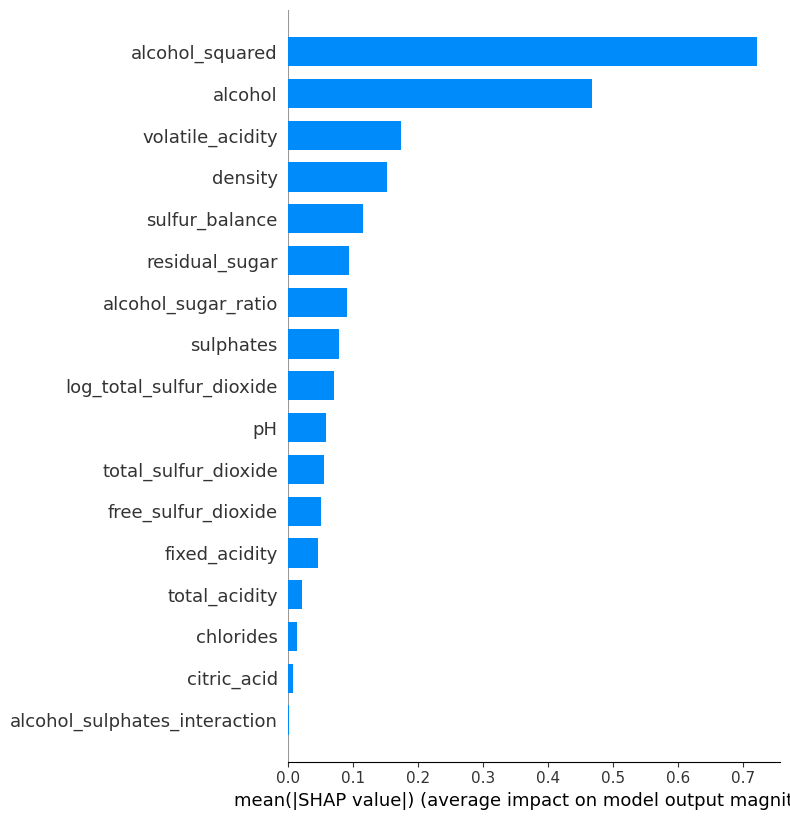

Top 5 features by SHAP (full model):
alcohol_squared     0.721098
alcohol             0.468548
volatile_acidity    0.174985
density             0.152441
sulfur_balance      0.115232
dtype: float64


In [11]:
# SHAP for the complete model, and than compare selected
import shap

X_full = df.drop("quality", axis=1)
y = df["quality"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Train a linear model on the full standardized feature set (so SHAP can rank the top contributors from the full feature space).
model_full = LinearRegression()
model_full.fit(X_scaled, y)

# Create a DataFrame version of X_scaled so SHAP keeps feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_full.columns)

# For linear models, LinearExplainer is appropriate and efficient
explainer = shap.LinearExplainer(model_full, X_scaled)

# Compute SHAP values for all samples
shap_values = explainer.shap_values(X_scaled)

# Bar plot shows mean(|SHAP|) per feature = global importance ranking
shap.summary_plot(shap_values, X_scaled_df, plot_type="bar")

# Extract Top-5 features numerically

# mean absolute contribution per feature:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=X_full.columns).sort_values(ascending=False)

top5_shap = shap_importance.head(5)
print("Top 5 features by SHAP (full model):")
print(top5_shap)



   - Do these match the features you selected in the "Feature Selection" step?




In [ ]:
# Comparison of similarities and differences between RFE, Lasso, and SHAP:

# Similarities:
# All three methods consistently identified alcohol_squared and volatile_acidity as key features.
# In addition, sulfur_balance appears in RFE, Lasso, and SHAP, which indicates that these
# features are stable and robust predictors of wine quality across different approaches.

# Differences:
# RFE selected fixed_acidity and alcohol, emphasizing features that contribute in a complementary
# way to overall model performance, even if their individual effect is not the strongest.

# Lasso selected alcohol_sulphates_interaction and alcohol_sugar_ratio, preferring features with
# strong independent linear impact under sparsity constraints, while excluding features such as
# density that do not show a dominant standalone effect.

# SHAP, in contrast, highlighted alcohol and density as important contributors to the model’s
# predictions, even though these features were not selected by Lasso and only partially (alcohol) by RFE.
# This happens because SHAP does not select features based on coefficient strength or elimination
# strategy, but instead measures the actual contribution of each feature to the final predictions.

# As a result, SHAP captures the real influence of features like density that affect the model’s
# decisions in practice.



7. ## **Local Explanation:** (5 points)
   - Pick two specific wine samples from the test set. One with high prediction and one with low prediction.
   - Use visualizations to explain why the model gave these specific scores.

High prediction: 8.18662770078255
Low prediction: 3.9907650118398994


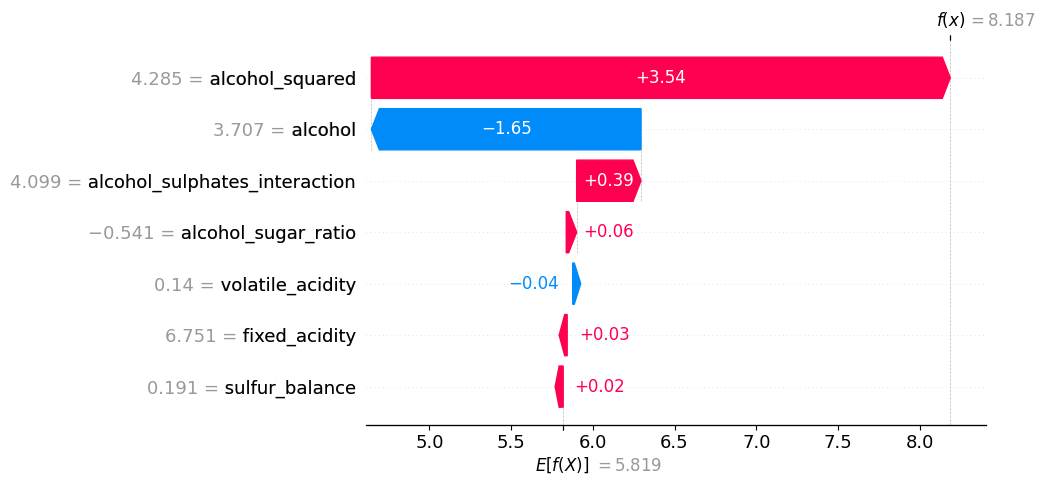

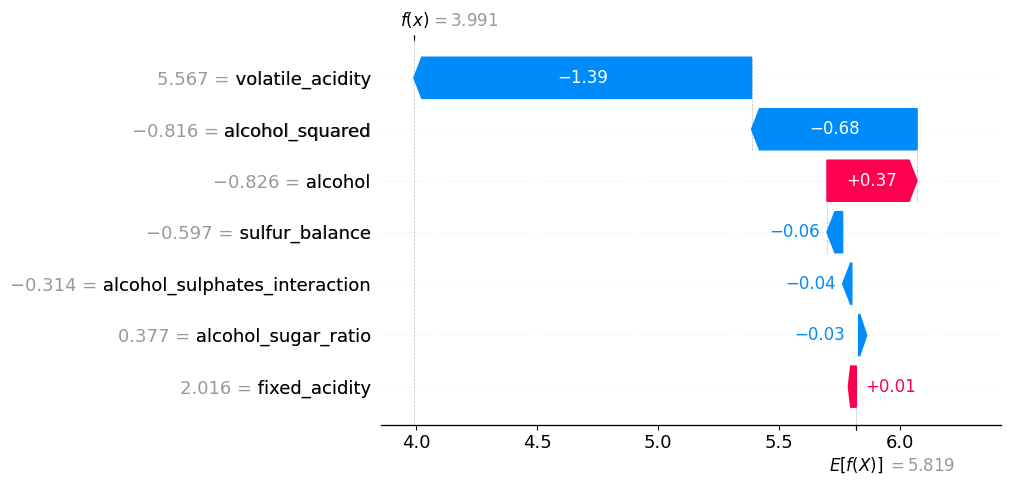

In [12]:
# NOTE : implemented base on our selected model that takes only the selected features
 # (we assumed that after the selection the goal is to test the model we created and not the complete one with all features)


# choose the highest and lowest predicted smaples:

# Predict on the test set (model is the model with selected features)
y_test_pred = model.predict(X_test_scaled)

# Index of highest and lowest predicted quality
high_idx = np.argmax(y_test_pred)
low_idx  = np.argmin(y_test_pred)

print("High prediction:", y_test_pred[high_idx])
print("Low prediction:",  y_test_pred[low_idx])

# Explanations using SHAP:

# Matching definitions with te selected feature model created above in the cell after RFE & LASSO:

feature_names = selected_features

# DataFrame with feature names for the scaled test data
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)


# Build SHAP explainer and compute SHAP values for the test set
explainer = shap.LinearExplainer(model, X_train_scaled)

shap_values_test = explainer.shap_values(X_test_scaled)

# High prediction sample explanation
shap.waterfall_plot(shap.Explanation(values=shap_values_test[high_idx], base_values=explainer.expected_value,
                                     data=X_test_scaled_df.iloc[high_idx], feature_names=feature_names))

# Low prediction sample explanation
shap.waterfall_plot(shap.Explanation(values=shap_values_test[low_idx],base_values=explainer.expected_value,
                                     data=X_test_scaled_df.iloc[low_idx], feature_names=feature_names))


In [ ]:
# Local SHAP Explanations:

# The local explanations are based on the final model that was chosen after the feature selection stage.
# This model uses the UNION of the important features selected by RFE and Lasso.
# Therefore, the SHAP plots reflect the real behavior of the model used for prediction.

# Two extreme samples from the test set were analyzed:
# - One with the highest predicted quality.
# - One with the lowest predicted quality.

# SHAP waterfall plots break each prediction into feature-level contributions,
# showing how every feature moves the prediction above or below the baseline

# High prediction sample (f(x) ≈ 8.19):

# Main positive drivers:
#    alcohol_squared (+3.54) = strong non-linear alcohol effect greatly increases quality.
#    alcohol_sulphates_interaction (+0.39) -> combined effect of alcohol and sulphates adds to quality.
#
# Main negative effect:
#   * alcohol (-1.65) -> linear alcohol term slightly reduces the prediction here.

# Conclusion:
#   The very high prediction is mainly driven by the non-linear alcohol effect (alcohol_squared),
#   showing that quality increases strongly at certain alcohol levels,
#   even when the linear alcohol term is negative.

# Low prediction sample (f(x) ≈ 3.99):

# Main negative driver:
#   volatile_acidity (-1.39) = high volatile acidity strongly reduces quality.
#   squared_alcohol slightly affects negativly (0.68).
#
# Weak positive effect:
#   alcohol (+0.37) = small compensation, not enough to offset negatives.

# Conclusion:
#   The low prediction is mainly explained by high volatile acidity
#   and unfavorable alcohol-related effects, which pull the score far below the baseline.

# Overall takeaway
# Across both local explanations, alcohol-related features dominate the model’s decisions:
# In addition, volatile acidity plays a critical role in lowering quality for low-scoring wines.


8. ## **Report:** (5 points)
   - Write a detailed report explaining each step of your process, including code snippets and results. Discuss the impact of your feature engineering and selection on the model's performance.
   - Provide visualizations where applicable to support your findings.

# Reports goes here

# Machine Learning Assignment : Final Report  
**Topic:** Feature Generation, Feature Engineering, Feature Selection & Model Explanation  
**Dataset:** Wine Quality Dataset (UCI)

The goal of this was to build a machine learning model for predicting wine quality as a consequense of examination of feature generation, feature engineering, and feature selection on the data set.

## Data structure :
The dataset contains different measurements of wines and a numerical target (quality).

---
## Steps:
---

## Exploratory Data Analysis (EDA)

**Tools used:**
- `df.describe()` for statistics  
- Histograms for feature distributions  
- Correlation heatmap  
- Correlation analysis with the target (quality)

---

### Conclusions

1. **Data completeness**  
   From `df.describe()`, there are no missing values in the dataset, so no imputation is required.

2. **Feature scales**  
   The features are measured on very different scales (e.g., alcohol vs. sulfur dioxide), therefore **normalization is necessary** before applying most machine learning models.

3. **Target distribution**  
   The quality scores are not evenly distributed and most wines have scores of **5 or 6**, indicating a **mild class imbalance** that should be considered when interpreting the results.

4. **Feature distributions**  
   - **Alcohol** exhibits a right-skewed distribution with relatively high variance, indicating potential importance.  
   - **pH** follows an approximately normal distribution, reflecting stable acidity levels.  
   - **Fixed acidity** shows moderate variability across samples.  
   - **Free** and **total sulfur dioxide** display highly skewed distributions with long right tails, suggesting that extreme preservation levels may affect wine quality and are informative for modeling.  
   Overall, alcohol, acidity measures, and sulfur dioxide emerge as important features for further analysis.

5. **Correlation heatmap insights**  
   - A strong positive correlation exists between **free sulfur dioxide** and **total sulfur dioxide**, which is expected due to their natural chemical relationship.  
   - A noticeable **negative correlation** appears between **density** and **alcohol**, reflecting known physical and chemical properties of wine.

6. **Correlation with the target (quality)**  
   - **Alcohol** shows the strongest positive relationship with wine quality.  
   - **Density** shows a relatively strong negative relationship with quality, indicating that denser wines tend to receive lower quality scores.

---

### Overall EDA Summary
The exploratory analysis highlights **alcohol content**, **acidity-related measures**, **sulfur dioxide levels**, and **density** as key variables influencing wine quality.  
These findings strongly motivate the subsequent steps of **feature generation**, **feature engineering**, and **feature selection**.


## Feature Generation

New features were created to capture meaningful chemical and physical relationships that are not explicitly represented in the raw dataset.

**Generated features:**

1. **alcohol_sugar_ratio = alcohol / (residual sugar + 1)**  
   Represents the balance between alcohol content and sweetness, which may influence taste perception.

2. **total_acidity = fixed acidity + volatile acidity + citric acid**  
   Combines different acidity measures into a single index that reflects the overall acidity profile of the wine.

3. **sulfur_balance = free sulfur dioxide / (total sulfur dioxide + 1)**  
   Measures the proportion of active sulfur relative to total sulfur content, capturing preservation effectiveness.

---

## Feature Engineering

Existing features were transformed to improve model expressiveness and handle non-linear patterns.

**Engineered features:**

1. **log_total_sulfur_dioxide = log(1 + total sulfur dioxide)**  
   Reduces skewness and limits the influence of extreme values.

2. **alcohol_squared = alcohol²**  
   Captures a non-linear relationship between alcohol content and wine quality.

3. **alcohol_sulphates_interaction = alcohol X sulphates**  
   Models interaction effects where the influence of alcohol depends on sulphate levels.

**Impact:**  
These transformations allow a linear model to capture **non-linear and conditional effects**, improving both predictive power and interpretability.

---

## Feature Selection

Two complementary methods were applied to identify the most important features.

### 1. Recursive Feature Elimination (RFE)

**Selected features:**  
- fixed_acidity  
- volatile_acidity  
- alcohol  
- sulfur_balance  
- alcohol_squared  

RFE favors features that contribute in a complementary way to overall model performance.

---

### 2. Lasso Regression (Top-5 by coefficient magnitude)

**Selected features:**  
- alcohol_squared  
- volatile_acidity  
- sulfur_balance  
- alcohol_sulphates_interaction  
- alcohol_sugar_ratio  

Lasso promotes sparsity and prioritizes features with strong independent predictive power.

---

### Comparison

Both methods consistently selected **alcohol_squared**, **volatile_acidity**, and **sulfur_balance**, indicating that these variables are robust predictors of wine quality.  

RFE additionally selected **fixed_acidity** and **alcohol**, emphasizing structural and complementary effects, while Lasso selected **alcohol_sulphates_interaction** and **alcohol_sugar_ratio**, favoring features with strong standalone influence under regularization.

---

## Model Building and Evaluation

A **Linear Regression** model was trained using the **union** of features selected by RFE and Lasso.

**Final feature set:**  
- alcohol  
- volatile_acidity  
- alcohol_squared  
- sulfur_balance  
- alcohol_sulphates_interaction  
- alcohol_sugar_ratio  
- fixed_acidity  

**Performance:**  
- **MAE:** 0.566  
- **MSE:** 0.538
- **R²:** 0.272

**Interpretation:**  
The model predicts wine quality with an average error of about **0.5 points** and explains approximately **27%** of the variance, showing that a compact but well-engineered feature set can achieve meaningful predictive performance.

---

## Global Explanation : SHAP

SHAP was applied to a model trained on the **full standardized feature set** in order to obtain a global explanation of feature importance.

**Top-5 features by SHAP:**  
1. alcohol_squared  
2. alcohol  
3. volatile_acidity  
4. density  
5. sulfur_balance  

**Insights:**  
There is strong agreement between **RFE, Lasso, and SHAP** on the importance of alcohol-related features and acidity balance.  
However, SHAP uniquely highlights **density**, showing that although it was not selected by RFE or Lasso, it still plays a meaningful role in the model predictions.  

This difference reflects the distinct purposes of the methods:  
- **RFE** selects features based on iterative performance improvement.  
- **Lasso** selects features by enforcing sparsity through regularization.  
- **SHAP** explains how features actually contribute to the model predictions.

---

## Local Explanation : SHAP

Local explanations were performed on the **final selected-feature model**, which uses the union of important features identified by RFE and Lasso.

Two extreme samples from the test set were analyzed:
- **Highest predicted quality:** ≈ 8.19  
- **Lowest predicted quality:** ≈ 3.99  

### High prediction sample
The high-quality prediction is mainly driven by:
- **alcohol_squared**, showing a strong non-linear alcohol effect.  
- **alcohol_sulphates_interaction**, capturing a positive interaction between alcohol and sulphates.  

Although the linear alcohol term is slightly negative, the squared term dominates, indicating a **non-linear relationship** where certain alcohol levels significantly boost perceived quality.

### Low prediction sample
The low-quality prediction is mainly explained by:
- **volatile_acidity**, which has a strong negative effect on taste and quality.  
- **alcohol_squared**, which in this range contributes negatively.  
- **sulfur_balance**, which slightly reduces the prediction.  

Positive contributions from alcohol are too weak to compensate for these effects.

**Conclusion:**  
Local predictions are primarily driven by **alcohol-related features and volatile acidity**, with sulfur balance and interaction terms playing secondary but meaningful roles.

---

## 11. Final Conclusion  

This Assignment demonstrates a complete and interpretable ML workflow:

- **EDA** guided understanding of the data.  
- **Feature generation & engineering** enriched representation.  
- **Feature selection** identified stable predictors.  
- **Model evaluation** showed solid performance (as MAE = 0.566, R² = 0.272).  
- **SHAP explanations** validated the importance of alcohol-related features and acidity.



#### Notes:
- Submit a Jupyter Notebook containing your code and full explanations.
- Include the dataset and any additional files needed to run your notebook inside the notebook.
- Ensure your notebook is well-documented with comments and markdown cells explaining your thought process.
- You are encouraged to explore different libraries and methods beyond what was covered in class.
- If you use any external resources or libraries, make sure to cite them appropriately in your notebook.
- Name of file should be changed to EX4_ID1_ID2

Good luck, and have fun exploring the power of feature engineering and selection!